# Проведите дисперсионный анализ сегментации клиентов
## Условие задачи

Вы работаете в онлайн-школе аналитиком. Вы знаете, что все клиенты школы были разделены на сегменты A/B/C/D на основе экспертной оценки. Это сделано, чтобы обеспечить высокий уровень клиентского сервиса.

Сейчас вы хотите оказывать клиентскую поддержку различным группам пользователей в зависимости от их возраста и наличия высшего образования. Ваша задача оценить, подходит ли текущая сегментация пользователей для новых задач или ее необходимо переделать.

**Формальное описание задачи:**

Оценить, влияет ли возраст и уровень образования на сегмент пользователя.

**Алгоритм решения:**

1. Загрузите данные из файла формата CSV.
2. Проведите предварительный анализ данных: изучите структуру набора данных, определите переменные, которые необходимо будет исследовать. Удалите наблюдения, в которых необходимые переменные пропущены.
3. Проведите One-way ANOVA и Two-way ANOVA.
4. Проверьте ограничения на применимость методов: нормальность и гомоскедастичность. Независимость наблюдений гарантируется.
5. Проведите апостериорный анализ при наличии статистически значимых результатов.
6. Сделайте выводы о влиянии уровня образования и возраста на сегмент пользователя.

**Входные данные:**

[Customer Segmentation.csv](https://github.com/Eduson-DataScience/DataScience/blob/main/EDA-Practice/Perform%20ANOVA/Customer%20Segmentation.csv)

## Подсказки

- Проверьте, что у вас есть файл с данными (Customer Segmentation.csv) и он находится в том же каталоге, что и ваш скрипт.
- Используйте метод `ols` из библиотеки statsmodels для проведения дисперсионного анализа.
- Для проверки нормальности остатков воспользуйтесь методом построения графика `qqplot` из библиотеки statsmodels, а для проверки гомоскедастичности остатков – `bartlett` из библиотеки scipy.
- Не забудьте провести апостериорный анализ для выявления групп, между которыми есть отличия в средних значениях.

In [47]:
import pandas as pd
import seaborn as sns
from scipy import stats

# anova model from formula
from statsmodels.formula.api import ols
# anova table from ols model
from statsmodels.stats.anova import anova_lm
# for qqplot
import statsmodels.api as sm
# tukey test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [25]:
data = pd.read_csv('Customer Segmentation.csv')
data.shape, data.head(), data.dtypes, data.info(), data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10695 non-null  int64  
 1   ID               10695 non-null  int64  
 2   Gender           10695 non-null  object 
 3   Ever_Married     10505 non-null  object 
 4   Age              10695 non-null  int64  
 5   Graduated        10593 non-null  object 
 6   Profession       10533 non-null  object 
 7   Work_Experience  9597 non-null   float64
 8   Spending_Score   10695 non-null  object 
 9   Family_Size      10247 non-null  float64
 10  Var_1            10587 non-null  object 
 11  Segmentation     10695 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1002.8+ KB


((10695, 12),
    Unnamed: 0      ID  Gender Ever_Married  Age Graduated     Profession  \
 0           0  460394  Female           No   32       Yes     Healthcare   
 1           1  461798  Female           No   56       Yes         Artist   
 2           2  464976    Male          Yes   75        No         Lawyer   
 3           3  462104    Male          Yes   39        No  Entertainment   
 4           4  464829    Male           No   22        No     Healthcare   
 
    Work_Experience Spending_Score  Family_Size  Var_1 Segmentation  
 0              9.0            Low          3.0  Cat_6            D  
 1              0.0            Low          1.0  Cat_6            A  
 2              1.0            Low          1.0  Cat_4            D  
 3              9.0            Low          2.0  Cat_3            D  
 4              9.0            Low          5.0  Cat_4            D  ,
 Unnamed: 0           int64
 ID                   int64
 Gender              object
 Ever_Married    

In [29]:
data.isnull().sum()

Unnamed: 0            0
ID                    0
Gender                0
Ever_Married        185
Age                   0
Graduated             0
Profession          154
Work_Experience    1082
Spending_Score        0
Family_Size         439
Var_1               108
Segmentation          0
dtype: int64

Нас интересует возраст, сегмент и уровень образования (Graduated), в последнем 102 значения пустых. Их надо удалить.

In [27]:
data = data.dropna(subset=['Graduated'])

<Axes: xlabel='Age', ylabel='Segmentation'>

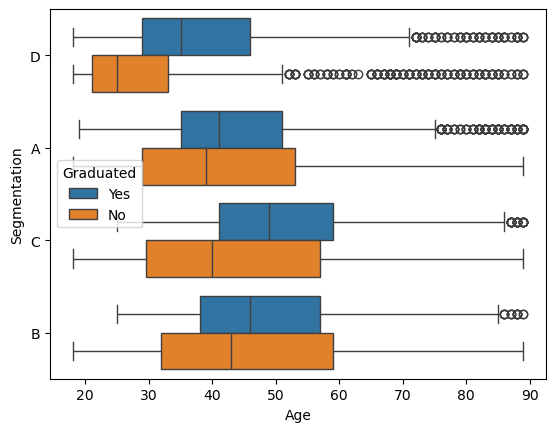

In [40]:
sns.boxplot(data=data, x='Age', y='Segmentation', hue='Graduated')

<b>Вопросы:</b>
1. Влияет ли возраст на сегмент?
2. Влияет ли образование на сегмент?
3. Влияет ли и возраст и образование на сегмент?

<b>Шаг 1. Постановка гипотез:</b>
    
$H_0$: сегмент не зависит ни от возраста, ни от образования, ни от того и другого.

$H_1$: сегмент зависит и от возраста и от образования.

<b>Шаг 2. Выбор уровня значимости:</b>
$$\alpha = 0.05$$

<b>Шаг 3. Проведение дисперсионного анализа:</b>

In [52]:
sample_gr_y = data[data.Graduated == 'Yes'].Age
sample_gr_n = data[data.Graduated == 'No'].Age

In [53]:
stats.f_oneway(sample_gr_y, sample_gr_n)

F_onewayResult(statistic=623.8044391240554, pvalue=7.904615485972818e-134)

In [56]:
sample_sgmt_a = data[data.Segmentation == 'A'].Age
sample_sgmt_b = data[data.Segmentation == 'B'].Age
sample_sgmt_c = data[data.Segmentation == 'C'].Age
sample_sgmt_d = data[data.Segmentation == 'D'].Age

In [58]:
stats.f_oneway(sample_sgmt_a, sample_sgmt_b, sample_sgmt_c, sample_sgmt_d)

F_onewayResult(statistic=477.9522267715545, pvalue=2.7981073172492912e-291)

In [61]:
model_gr = ols('Age ~ Graduated', data).fit()
anova_lm(model_gr)

,df,sum_sq,mean_sq,F,PR(>F)
Graduated,1.0,1.651607e+05,165160.651826,623.804439,7.904615e-134
Residual,10591.0,2.804110e+06,264.763508,NaN,NaN


In [65]:
model_sgmt = ols('Age ~ Segmentation', data).fit()
anova_lm(model_sgmt)

,df,sum_sq,mean_sq,F,PR(>F)
Segmentation,3.0,3.541179e+05,118039.307058,477.952227,2.798107e-291
Residual,10589.0,2.615153e+06,246.968840,NaN,NaN


In [66]:
stats.shapiro(model_gr.resid)

C:\Users\iTonyJah\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10593.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9226730569499952, pvalue=1.3838949126710102e-58)

In [67]:
stats.shapiro(model_sgmt.resid)

ShapiroResult(statistic=0.9366341967822318, pvalue=6.690934279113242e-55)

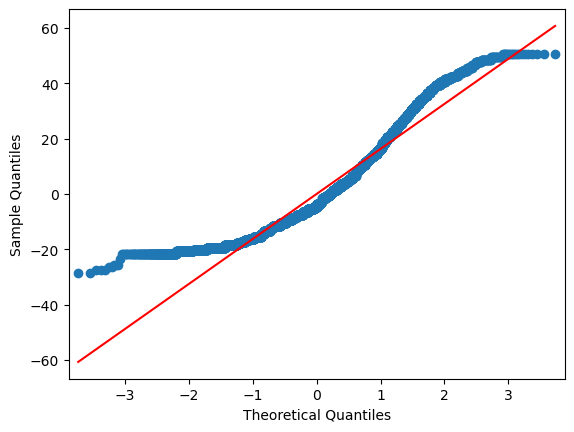

In [72]:
sm.qqplot(model_gr.resid, line='s');

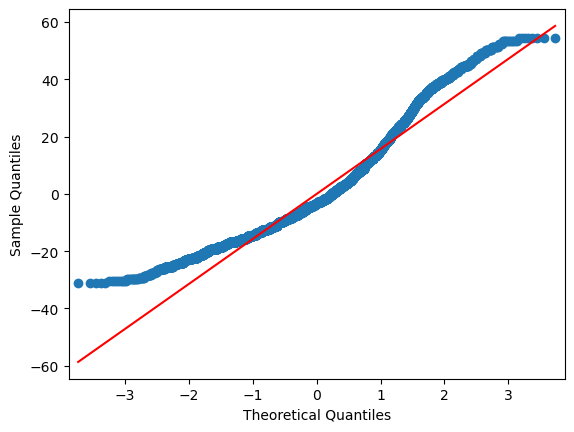

In [73]:
sm.qqplot(model_sgmt.resid, line='s');

In [75]:
stats.bartlett(sample_sgmt_a, sample_sgmt_b, sample_sgmt_c, sample_sgmt_d)

BartlettResult(statistic=43.343925439063604, pvalue=2.0801005394433813e-09)

In [105]:
mod_sgmt = ols('Age ~ Segmentation', data).fit()
anova_lm(mod_sgmt)

,df,sum_sq,mean_sq,F,PR(>F)
Segmentation,3.0,3.541179e+05,118039.307058,477.952227,2.798107e-291
Residual,10589.0,2.615153e+06,246.968840,NaN,NaN


In [106]:
mod_gr = ols('Age ~ Graduated', data).fit()
anova_lm(mod_gr)

,df,sum_sq,mean_sq,F,PR(>F)
Graduated,1.0,1.651607e+05,165160.651826,623.804439,7.904615e-134
Residual,10591.0,2.804110e+06,264.763508,NaN,NaN


In [81]:
print(pairwise_tukeyhsd(endog=data.Age, groups=data.Segmentation, alpha=0.05))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B   3.2986    0.0   2.1722    4.425   True
     A      C   4.8721    0.0   3.7504   5.9938   True
     A      D  -9.6403    0.0 -10.7026  -8.5781   True
     B      C   1.5735 0.0029   0.4084   2.7386   True
     B      D -12.9389    0.0 -14.0468  -11.831   True
     C      D -14.5124    0.0 -15.6156 -13.4093   True
------------------------------------------------------


In [82]:
print(pairwise_tukeyhsd(endog=data.Age, groups=data.Graduated, alpha=0.05))

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
    No    Yes   8.1359   0.0 7.4974 8.7744   True
-------------------------------------------------


In [108]:
two_way = ols('Age ~ Graduated + Segmentation + Graduated:Segmentation', data).fit()
anova_lm(two_way)

,df,sum_sq,mean_sq,F,PR(>F)
Graduated,1.0,1.651607e+05,165160.651826,690.905695,1.446251e-147
Segmentation,3.0,2.450555e+05,81685.173479,341.708215,8.220507e-212
Graduated:Segmentation,3.0,2.871598e+04,9571.992294,40.041886,1.011249e-25
Residual,10585.0,2.530339e+06,239.049487,NaN,NaN


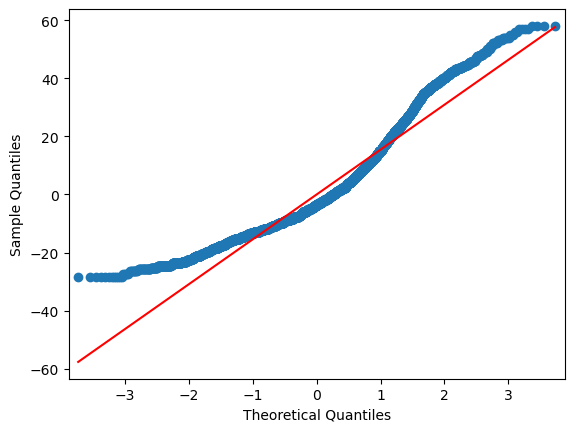

In [109]:
sm.qqplot(two_way.resid, line='s');

In [102]:
sample_a_y = data[(data.Segmentation == 'A') & (data.Graduated == 'Yes')].Age
sample_b_y = data[(data.Segmentation == 'B') & (data.Graduated == 'Yes')].Age
sample_c_y = data[(data.Segmentation == 'C') & (data.Graduated == 'Yes')].Age
sample_d_y = data[(data.Segmentation == 'D') & (data.Graduated == 'Yes')].Age

sample_a_n = data[(data.Segmentation == 'A') & (data.Graduated == 'No')].Age
sample_b_n = data[(data.Segmentation == 'B') & (data.Graduated == 'No')].Age
sample_c_n = data[(data.Segmentation == 'C') & (data.Graduated == 'No')].Age
sample_d_n = data[(data.Segmentation == 'D') & (data.Graduated == 'No')].Age

In [103]:
stats.bartlett(sample_a_y, sample_b_y, sample_c_y, sample_d_y, sample_a_n, sample_b_n, sample_c_n, sample_d_n)

BartlettResult(statistic=233.96193752334233, pvalue=7.142053955616402e-47)

In [104]:
data['combination'] = data.Segmentation + '/' + data.Graduated

print(pairwise_tukeyhsd(endog=data.Age, groups=data.combination, alpha=0.05))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
  A/No  A/Yes   1.3896 0.2931  -0.4414   3.2206  False
  A/No   B/No   2.8664 0.0037   0.5767   5.1561   True
  A/No  B/Yes   4.6981    0.0   2.8575   6.5387   True
  A/No   C/No   0.2673    1.0  -2.3012   2.8358  False
  A/No  C/Yes   7.1141    0.0   5.3191   8.9092   True
  A/No   D/No -12.5708    0.0 -14.3916 -10.7499   True
  A/No  D/Yes  -3.1845    0.0  -5.1587  -1.2103   True
 A/Yes   B/No   1.4768 0.3962  -0.6262   3.5798  False
 A/Yes  B/Yes   3.3085    0.0   1.7061   4.9109   True
 A/Yes   C/No  -1.1223 0.8505  -3.5258   1.2813  False
 A/Yes  C/Yes   5.7245    0.0   4.1747   7.2744   True
 A/Yes   D/No -13.9604    0.0 -15.5401 -12.3806   True
 A/Yes  D/Yes  -4.5741    0.0  -6.3283  -2.8199   True
  B/No  B/Yes   1.8317 0.1452  -0.2796   3.9431  False
  B/No   C/No   -2.599 0.0843   -5.368     0.17  False
  B/No  C/